<a href="https://colab.research.google.com/github/sada1908/edyoda_mldl/blob/main/Edyoda_DLFundamentals_Assign01_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Handwritten  Digit Recognition **

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
from tensorflow.keras.datasets import cifar10

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras import Sequential,layers

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix , accuracy_score , ConfusionMatrixDisplay

In [ ]:
from tensorflow.keras.models import load_model

# **Assignment 01**

In [ ]:
(x_train , y_train) , (x_test , y_test) = mnist.load_data()
print("Train:",x_train.shape , y_train.shape , "| Test:",x_test.shape , y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28) (60000,) | Test: (10000, 28, 28) (10000,)


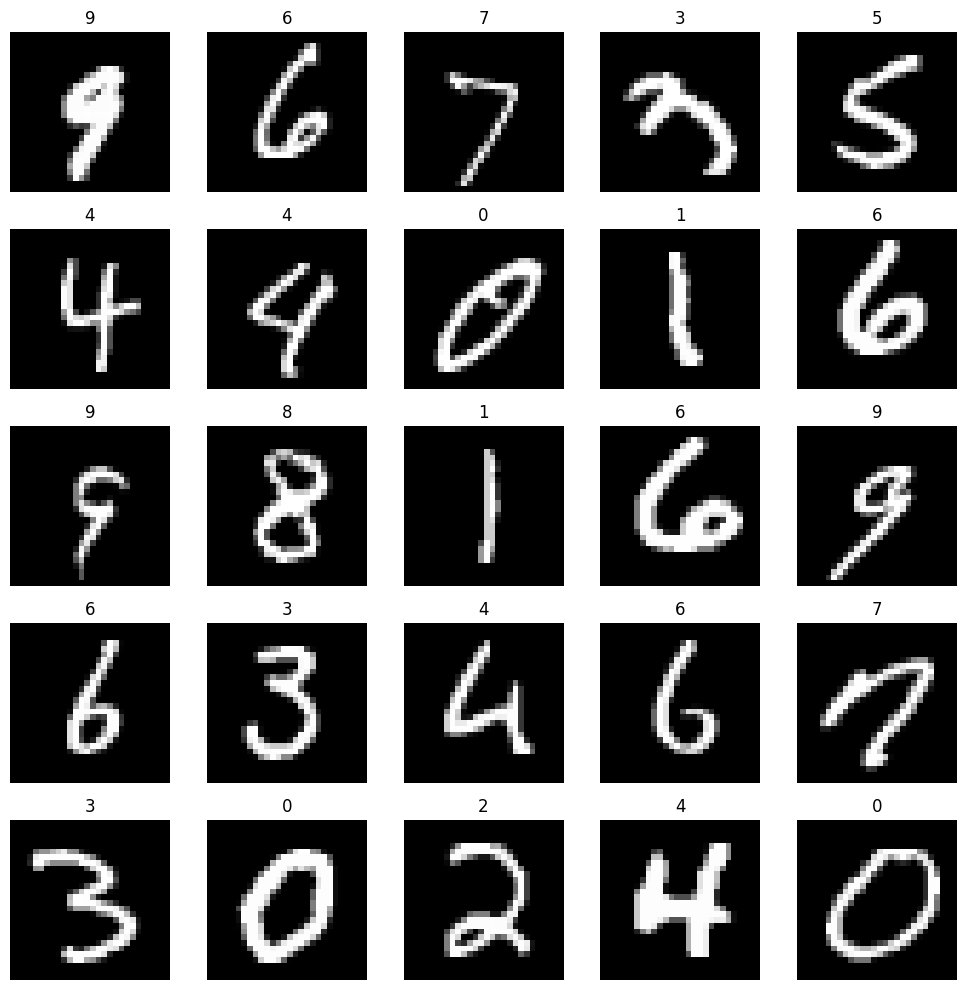

In [ ]:
fig,axes = plt.subplots(5,5,figsize=(10,10))
idxs = np.random.choice(len(x_train),25,replace = False)
for ax,i in zip(axes.flatten(),idxs):
  ax.imshow(x_train[i],cmap='gray')
  ax.set_title(y_train[i]);ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
num_classes = 10
x_train_n = (x_train/255.0).astype('float32')
x_test_n = (x_test/255.0).astype('float32')

y_train_oh = keras.utils.to_categorical(y_train,num_classes)
y_test_oh = keras.utils.to_categorical(y_test,num_classes)



In [ ]:
print(y_train_oh[0:5])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [ ]:
def make_mlp(hidden1 = 128 , hidden2 = 64 , dropout = 0.0):
  model = Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(hidden1,activation='relu'),
    layers.Dense(hidden2,activation='relu'),
    layers.Dropout(dropout),
    layers.Dense(num_classes,activation='softmax')
  ])
  model.compile(
      optimizer = keras.optimizers.Adam(),
      loss = 'categorical_crossentropy',
      metrics = ['accuracy']
  )
  return model

In [ ]:
model = make_mlp(128,64,dropout = 0.1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train_n,y_train_oh,batch_size=32,epochs=10,validation_split=0.2,verbose=2)

Epoch 1/10
1500/1500 - 11s - 7ms/step - accuracy: 0.9110 - loss: 0.3008 - val_accuracy: 0.9573 - val_loss: 0.1459
Epoch 2/10
1500/1500 - 4s - 2ms/step - accuracy: 0.9629 - loss: 0.1249 - val_accuracy: 0.9669 - val_loss: 0.1119
Epoch 3/10
1500/1500 - 4s - 3ms/step - accuracy: 0.9739 - loss: 0.0875 - val_accuracy: 0.9711 - val_loss: 0.0977
Epoch 4/10
1500/1500 - 4s - 3ms/step - accuracy: 0.9784 - loss: 0.0669 - val_accuracy: 0.9725 - val_loss: 0.0964
Epoch 5/10
1500/1500 - 4s - 2ms/step - accuracy: 0.9831 - loss: 0.0529 - val_accuracy: 0.9713 - val_loss: 0.1013
Epoch 6/10
1500/1500 - 4s - 2ms/step - accuracy: 0.9858 - loss: 0.0437 - val_accuracy: 0.9723 - val_loss: 0.0981
Epoch 7/10
1500/1500 - 4s - 3ms/step - accuracy: 0.9878 - loss: 0.0371 - val_accuracy: 0.9760 - val_loss: 0.0932
Epoch 8/10
1500/1500 - 4s - 3ms/step - accuracy: 0.9894 - loss: 0.0321 - val_accuracy: 0.9746 - val_loss: 0.0965
Epoch 9/10
1500/1500 - 4s - 2ms/step - accuracy: 0.9915 - loss: 0.0263 - val_accuracy: 0.9753 -

In [ ]:
def plot_history(h):
  plt.figure();plt.plot(h.history['accuracy']);plt.plot(h.history['val_accuracy'])
  plt.title('Accuracy');plt.xlabel('Epoch');plt.ylabel('Acc');plt.legend(['Train','Val']);plt.show()

  plt.figure();plt.plot(h.history['loss']);plt.plot(h.history['val_loss'])
  plt.title('Loss');plt.xlabel('Epoch');plt.ylabel('Loss');plt.legend(['Train','Val']);plt.show()

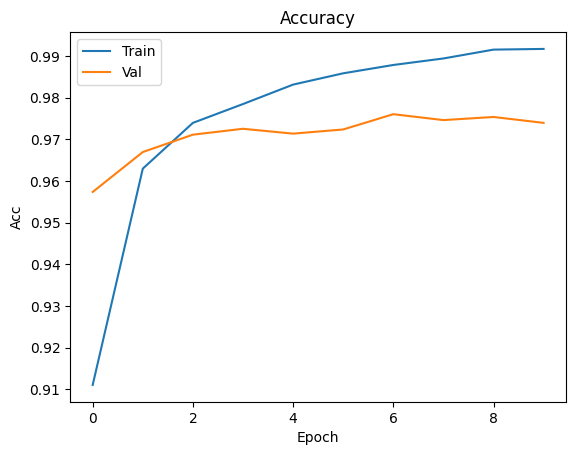

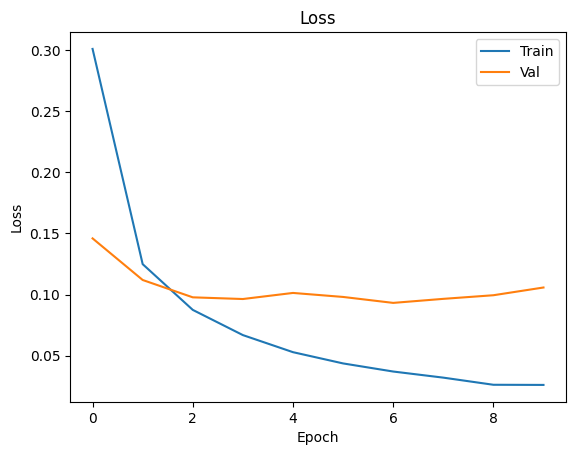

In [ ]:
plot_history(history)

Test Accuracy: 97.54%
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.95      0.98      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.97      0.97       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.94      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

[[ 970    0    1    2    2    0    1    1    1    2]
 [   0 1125    3    2    0    0    2    0    3    0]
 [   2    1 1011    7    4    0    0    3    4    0]
 [   1    1    4  992    0    5    0    3    1    3]
 [   1 

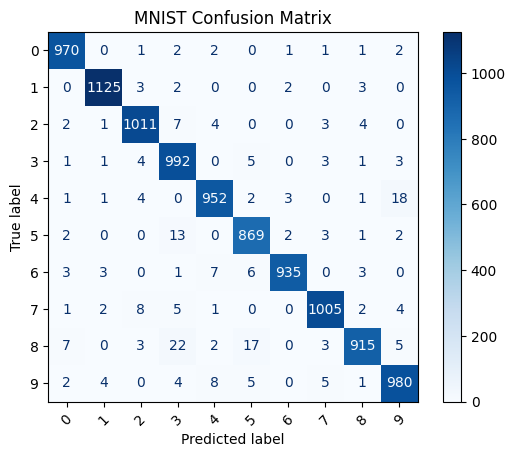

In [ ]:
test_loss , test_acc = model.evaluate(x_test_n,y_test_oh,verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = model.predict(x_test_n , verbose=0).argmax(axis=1)
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
print(cm)
ConfusionMatrixDisplay(cm).plot(cmap = 'Blues',xticks_rotation=45)
plt.title('MNIST Confusion Matrix')
plt.show()

In [ ]:
model.save('mnist_model.h5')

In [ ]:
mnist_model = load_model('mnist_model.h5')

In [ ]:
mnist_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,388 (427.30 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
mnist_model.compile(
      optimizer = keras.optimizers.Adam(),
      loss = 'categorical_crossentropy',
      metrics = ['accuracy']
  )
mnist_model.evaluate(x_test_n,y_test_oh,verbose=0)

[0.09045303612947464, 0.9753999710083008]

In [ ]:
# predict from a test set
pred_new = mnist_model.predict(x_test_n[0:10])
print(pred_new.argmax(axis=1),y_test[0:10])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[7 2 1 0 4 1 4 9 5 9] [7 2 1 0 4 1 4 9 5 9]


# `**Assignment 02 - Convulational Neural Network**

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [ ]:
(x_train , y_train) , (x_test , y_test) = cifar10.load_data()
print("Train:",x_train.shape , y_train.shape , "| Test:",x_test.shape , y_test.shape)

Train: (50000, 32, 32, 3) (50000, 1) | Test: (10000, 32, 32, 3) (10000, 1)


In [ ]:
num_classes = 10

In [ ]:
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0
y_train_oh = keras.utils.to_categorical(y_train,num_classes)
y_test_oh = keras.utils.to_categorical(y_test,num_classes)

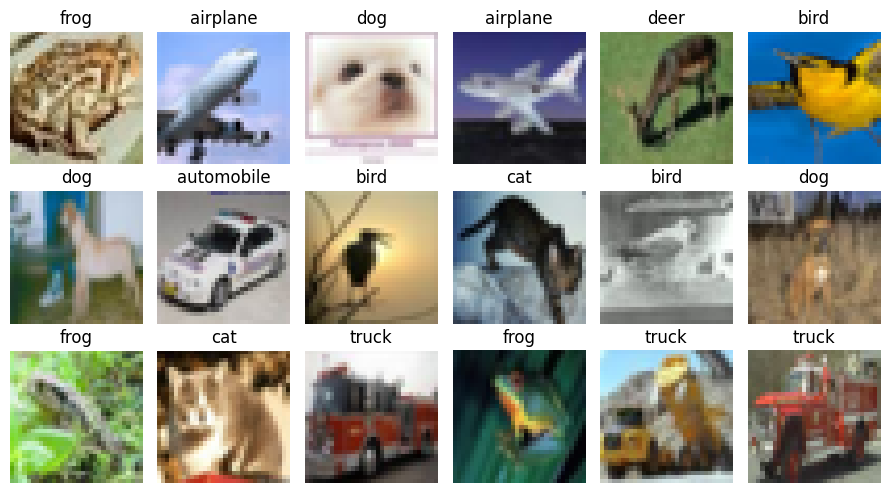

In [ ]:
fig,axes = plt.subplots(3,6,figsize=(9,5))
idxs = np.random.choice(len(x_train),18,replace = False)
for ax,i in zip(axes.flatten(),idxs):
  # Scale the normalized image data back to the 0-255 range for display
  ax.imshow((x_train[i] * 255).astype(np.uint8))
  ax.set_title(class_names[y_train[i][0]]);ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
def make_cnn():
  inputs = keras.Input(shape=(32,32,3))
  x = data_augmentation(inputs)
  for filters in [32,64,128]:
    x = layers.Conv2D(filters,3,padding = 'same',activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters,3,padding = 'same',activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

  x = layers.Flatten()(x)
  x = layers.Dense(256,activation='relu')(x)
  x = layers.Dropout(0.2)(x)
  outputs = layers.Dense(num_classes,activation='softmax')(x)
  model = keras.Model(inputs,outputs)
  model.compile(optimizer=keras.optimizers.Adam(),
                loss = 'categorical_crossentropy',
                metrics = ['accuracy'])
  return model

In [ ]:
cnn = make_cnn()
cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 815,914 (3.11 MB)

 Trainable params: 815,018 (3.11 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
cb = [
    keras.callbacks.EarlyStopping(monitor = 'val_loss',patience=5,restore_best_weights=True)
]
hist_cnn = cnn.fit(x_train,y_train_oh,batch_size=64,epochs=50,validation_split=0.2,callbacks=cb,verbose=2)

Epoch 1/50
625/625 - 23s - 36ms/step - accuracy: 0.3797 - loss: 1.7172 - val_accuracy: 0.4549 - val_loss: 1.5207
Epoch 2/50
625/625 - 12s - 18ms/step - accuracy: 0.5049 - loss: 1.3733 - val_accuracy: 0.5139 - val_loss: 1.3696
Epoch 3/50
625/625 - 12s - 18ms/step - accuracy: 0.5614 - loss: 1.2296 - val_accuracy: 0.6073 - val_loss: 1.1128
Epoch 4/50
625/625 - 11s - 18ms/step - accuracy: 0.6018 - loss: 1.1214 - val_accuracy: 0.6176 - val_loss: 1.1307
Epoch 5/50
625/625 - 11s - 18ms/step - accuracy: 0.6332 - loss: 1.0465 - val_accuracy: 0.6241 - val_loss: 1.1028
Epoch 6/50
625/625 - 12s - 19ms/step - accuracy: 0.6565 - loss: 0.9851 - val_accuracy: 0.6846 - val_loss: 0.8885
Epoch 7/50
625/625 - 12s - 19ms/step - accuracy: 0.6741 - loss: 0.9406 - val_accuracy: 0.7088 - val_loss: 0.8422
Epoch 8/50
625/625 - 12s - 19ms/step - accuracy: 0.6838 - loss: 0.9114 - val_accuracy: 0.6870 - val_loss: 0.9035
Epoch 9/50
625/625 - 12s - 19ms/step - accuracy: 0.7001 - loss: 0.8689 - val_accuracy: 0.7208 - 

In [ ]:
test_acc = cnn.evaluate(x_test,y_test_oh,verbose=0)[1]
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 77.62%


In [ ]:
y_pred = cnn.predict(x_test).argmax(axis=1)
print(classification_report(y_test,y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      1000
           1       0.79      0.96      0.87      1000
           2       0.65      0.75      0.70      1000
           3       0.71      0.53      0.60      1000
           4       0.78      0.73      0.76      1000
           5       0.79      0.66      0.72      1000
           6       0.80      0.83      0.82      1000
           7       0.75      0.85      0.80      1000
           8       0.92      0.81      0.86      1000
           9       0.84      0.84      0.84      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.77     10000
weighted avg       0.78      0.78      0.77     10000



In [ ]:
print(classification_report(y_test.squeeze(),y_pred,target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.75      0.81      0.78      1000
  automobile       0.79      0.96      0.87      1000
        bird       0.65      0.75      0.70      1000
         cat       0.71      0.53      0.60      1000
        deer       0.78      0.73      0.76      1000
         dog       0.79      0.66      0.72      1000
        frog       0.80      0.83      0.82      1000
       horse       0.75      0.85      0.80      1000
        ship       0.92      0.81      0.86      1000
       truck       0.84      0.84      0.84      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.77     10000
weighted avg       0.78      0.78      0.77     10000



32


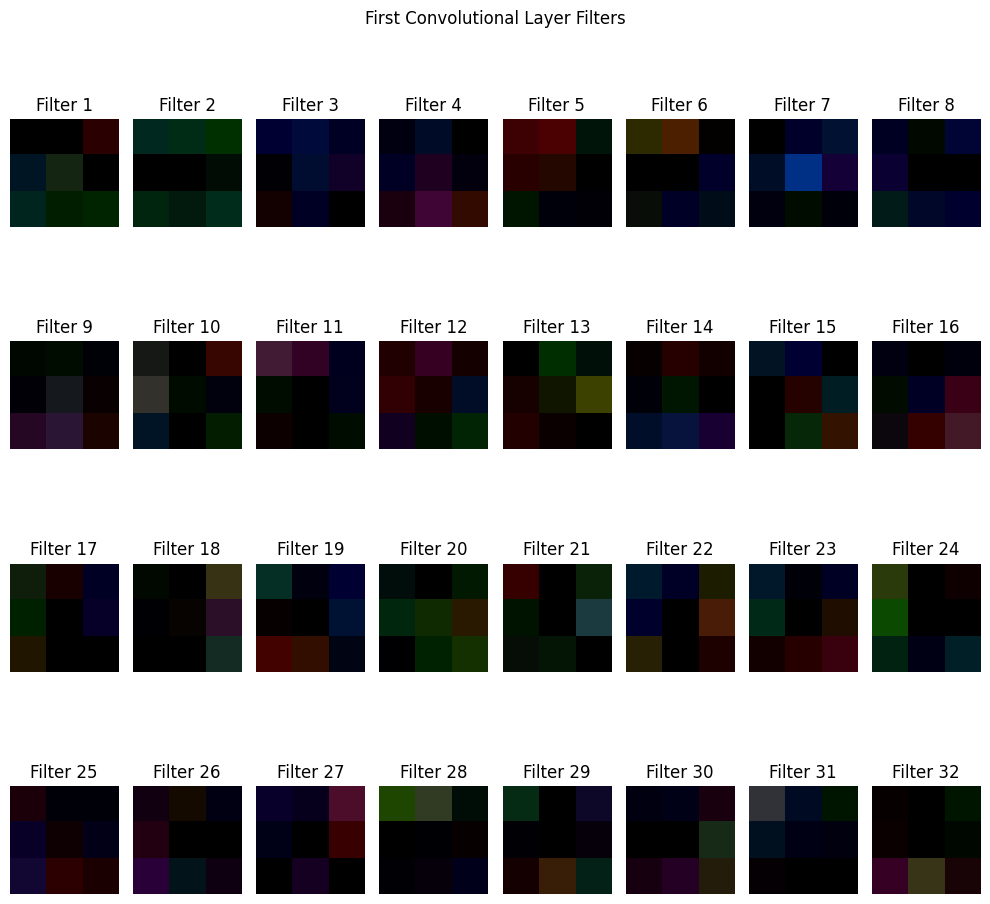

In [ ]:
first_conv = None
for layer in cnn.layers:
  if isinstance(layer,layers.Conv2D):
    first_conv = layer
    break

if first_conv is not None:
  weights = first_conv.get_weights()[0]
  n_filters  = weights.shape[-1]
  print(n_filters)
  cols = 8
  rows = int(np.ceil(n_filters/cols))
  fig,axes = plt.subplots(rows,cols,figsize=(10,10))
  for i in range(rows*cols):
    ax = axes.ravel()[i]
    if i<n_filters:
      w = weights[:,:,:,i]
      w_min , w_max = w.min(),w.max()
      img  = (w-w_min)/(w_max-w_min + 1e7)
      ax.imshow(weights[:,:,:,i],cmap='gray')
      ax.set_title(f'Filter {i+1}')
      ax.axis('off')
  fig.suptitle('First Convolutional Layer Filters')
  plt.tight_layout()
  plt.show()
else:
  print("No convolutional layer found in the model.")


In [ ]:
# save model
cnn.save('cifar10_model.h5')

In [ ]:
cifar_model = load_model('cifar10_model.h5')

In [ ]:
cifar_model.compile(optimizer=keras.optimizers.Adam(),
                loss = 'categorical_crossentropy',
                metrics = ['accuracy'])
cifar_model.evaluate(x_test,y_test_oh,verbose=0)

[0.6600863337516785, 0.7760999798774719]

In [ ]:
#predict random 10 data point sform test data
pred_images_new = cifar_model.predict(x_test[0:10])
print(pred_images_new.argmax(axis=1),y_test[0:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step
[3 8 8 0 6 6 1 6 3 1] [[3]
 [8]
 [8]
 [0]
 [6]
 [6]
 [1]
 [6]
 [3]
 [1]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


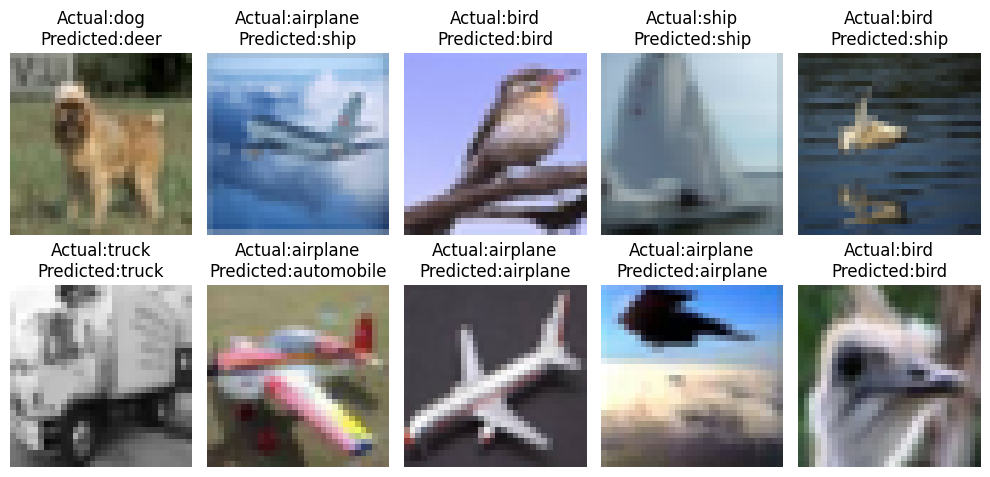

In [ ]:
# plot 5 images of predicted & actual images from random test data with labels
fig,axes = plt.subplots(2,5,figsize=(10,5))
idxs = np.random.choice(len(x_test),10,replace = False)
# Select random images and their corresponding true labels
random_test_images = x_test[idxs]
random_test_labels = y_test[idxs]

# Predict on the selected random images
pred_images_new = cifar_model.predict(random_test_images)

for ax,i in zip(axes.flatten(),range(10)):
  ax.imshow(random_test_images[i])
  ax.set_title(f'Actual:{class_names[random_test_labels[i][0]]}\nPredicted:{class_names[pred_images_new.argmax(axis=1)[i]]}')
  ax.axis('off')
plt.tight_layout()
plt.show()

# **Assignment 05 - Hyperparameter Optimization (CIFAR-10 CNN)**
Systematically tune LR, batch size, architecture, optimizer; use callbacks, compare with baseline.
We’ll reuse the CNN from Assignment 2 as the baseline.

In [ ]:
import time
baseline = make_cnn()
start = time.time()
hist_base = baseline.fit(
    x_train, y_train_oh, validation_split=0.2,
    epochs=10, batch_size=64, verbose=0
)
baseline_time = time.time() - start
baseline_acc = baseline.evaluate(x_test, y_test_oh, verbose=0)[1]
baseline_params = baseline.count_params()
print(f"Baseline: acc={baseline_acc:.4f}, time={baseline_time:.1f}s, params={baseline_params:,}")

Baseline: acc=0.7121, time=144.8s, params=815,914


# **5.2 LR Range Test (find a good LR window)**

LR 1e-05 -> best val acc 0.3698
LR 4e-05 -> best val acc 0.4657
LR 2e-04 -> best val acc 0.5133
LR 6e-04 -> best val acc 0.5416
LR 3e-03 -> best val acc 0.5228
LR 1e-02 -> best val acc 0.3005


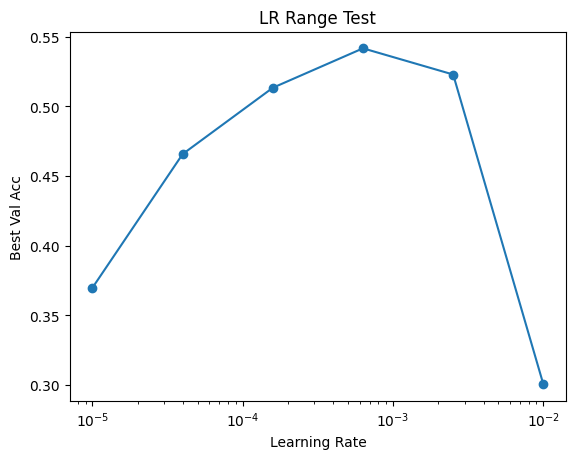

In [ ]:
lrs = np.logspace(-5, -2, 6)
accs = []
for lr in lrs:
    m = make_cnn()
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train, y_train_oh, validation_split=0.2, epochs=3, batch_size=64, verbose=0)
    accs.append(max(h.history['val_accuracy']))

for lr, a in zip(lrs, accs):
    print(f"LR {lr:.0e} -> best val acc {a:.4f}")

plt.plot(lrs, accs, marker='o'); plt.xscale('log'); plt.xlabel("Learning Rate"); plt.ylabel("Best Val Acc"); plt.title("LR Range Test"); plt.show()

Batch 16: test acc 0.7138
Batch 32: test acc 0.6341
Batch 64: test acc 0.6296
Batch 128: test acc 0.6824


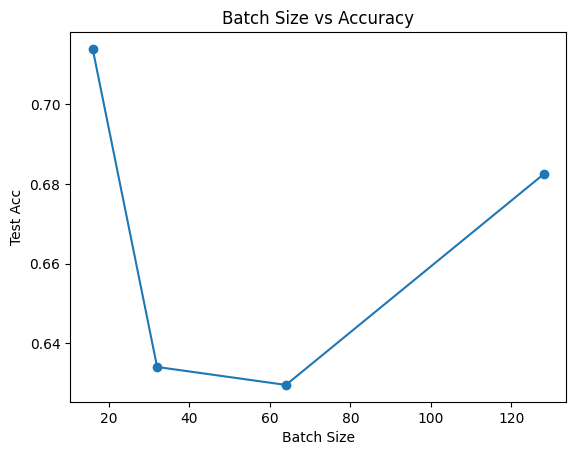

In [ ]:
batch_sizes = [16, 32, 64, 128]
bs_results = {}
for bs in batch_sizes:
    m = make_cnn()
    h = m.fit(x_train, y_train_oh, validation_split=0.2, epochs=8, batch_size=bs, verbose=0)
    acc = m.evaluate(x_test, y_test_oh, verbose=0)[1]
    bs_results[bs] = acc
    print(f"Batch {bs}: test acc {acc:.4f}")

plt.plot(batch_sizes, [bs_results[b] for b in batch_sizes], marker='o')
plt.xlabel("Batch Size"); plt.ylabel("Test Acc"); plt.title("Batch Size vs Accuracy"); plt.show()

In [ ]:
import keras_tuner as kt

def build_model(hp):
    filters1 = hp.Choice('filters1', [32, 64])
    filters2 = hp.Choice('filters2', [64, 128])
    filters3 = hp.Choice('filters3', [128, 256])
    dense_units = hp.Choice('dense', [128, 256, 384])
    dropout = hp.Choice('dropout', [0.3, 0.4, 0.5])
    lr = hp.Choice('lr', [1e-3, 5e-4, 1e-4])

    inputs = keras.Input(shape=(32,32,3))
    x = data_augmentation(inputs)

    for f in [filters1, filters2, filters3]:
        x = layers.Conv2D(f,3,padding='same')(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
        x = layers.Conv2D(f,3,padding='same')(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model, objective='val_accuracy',
    max_trials=6, executions_per_trial=1,
    directory='kt_cifar10', project_name='cnn_tune'
)
tuner.search(x_train, y_train_oh, validation_split=0.2, epochs=10, batch_size=64, verbose=0)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

Best hyperparameters: {'filters1': 32, 'filters2': 64, 'filters3': 128, 'dense': 384, 'dropout': 0.3, 'lr': 0.0005}


In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 11.5 MB/s eta 0:00:00


Adam: 0.7184
RMSprop: 0.7074
SGD_mom: 0.6603


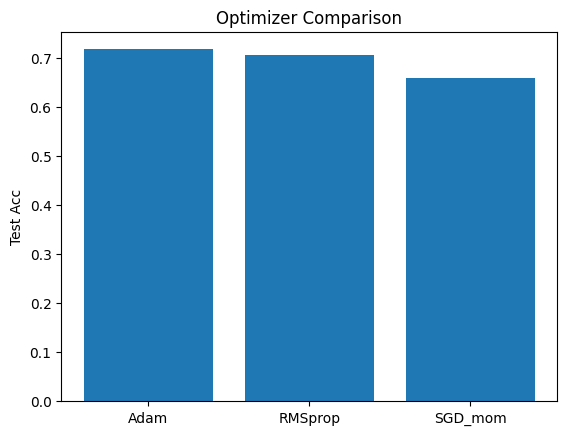

In [ ]:
opts = {
    "Adam": keras.optimizers.Adam(),
    "RMSprop": keras.optimizers.RMSprop(),
    "SGD_mom": keras.optimizers.SGD(momentum=0.9, nesterov=True)
}
opt_results = {}
for name, opt in opts.items():
    m = make_cnn()
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(x_train, y_train_oh, validation_split=0.2, epochs=8, batch_size=64, verbose=0)
    acc = m.evaluate(x_test, y_test_oh, verbose=0)[1]
    opt_results[name] = acc
    print(f"{name}: {acc:.4f}")

plt.bar(list(opt_results.keys()), list(opt_results.values()))
plt.ylabel("Test Acc"); plt.title("Optimizer Comparison"); plt.show()

In [ ]:
best_model = build_model(best_hp)
callbacks = [
    keras.callbacks.ModelCheckpoint("best_cifar10.keras", save_best_only=True, monitor='val_accuracy', mode='max'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

start = time.time()
hist_best = best_model.fit(
    x_train, y_train_oh,
    validation_split=0.2,
    epochs=25, batch_size=64, verbose=2,
    callbacks=callbacks
)
best_time = time.time() - start
best_acc = best_model.evaluate(x_test, y_test_oh, verbose=0)[1]
best_params = best_model.count_params()
print(f"Best: acc={best_acc:.4f}, time={best_time:.1f}s, params={best_params:,}")

Epoch 1/25
625/625 - 17s - 27ms/step - accuracy: 0.3608 - loss: 1.7676 - val_accuracy: 0.4389 - val_loss: 1.5334 - learning_rate: 5.0000e-04
Epoch 2/25
625/625 - 12s - 19ms/step - accuracy: 0.4703 - loss: 1.4611 - val_accuracy: 0.5036 - val_loss: 1.4313 - learning_rate: 5.0000e-04
Epoch 3/25
625/625 - 12s - 19ms/step - accuracy: 0.5209 - loss: 1.3226 - val_accuracy: 0.4863 - val_loss: 1.5167 - learning_rate: 5.0000e-04
Epoch 4/25
625/625 - 12s - 19ms/step - accuracy: 0.5607 - loss: 1.2252 - val_accuracy: 0.5748 - val_loss: 1.2014 - learning_rate: 5.0000e-04
Epoch 5/25
625/625 - 12s - 19ms/step - accuracy: 0.5915 - loss: 1.1512 - val_accuracy: 0.6244 - val_loss: 1.0735 - learning_rate: 5.0000e-04
Epoch 6/25


In [ ]:
print(f"Baseline -> acc={baseline_acc:.4f}, time={baseline_time:.1f}s, params={baseline_params:,}")
print(f"Best     -> acc={best_acc:.4f}, time={best_time:.1f}s, params={best_params:,}")
impr = (best_acc - baseline_acc)*100
print(f"Accuracy improvement: {impr:.2f} pp")

NameError: name 'baseline_acc' is not defined

# **Assignment 03 - Sentiment Analysis with LSTM's using tweet dataset**

In [ ]:
from datasets import load_dataset

In [ ]:
ds = load_dataset('tweet_eval','sentiment')
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
def clean_text(t):
  t = re.sub(r"http\S+","",t)
  t = re.sub(r"@[A-Za-z0-9_]+"," ",t)
  t = re.sub(r"[^A-Za-z0-9\s]"," ",t) # Modified to keep digits
  t = re.sub(r"@\w+","",t)
  t = re.sub(r"#","",t)
  t = re.sub(r"\s+"," ",t).strip()
  return t.lower()

In [ ]:
train_texts = [clean_text(t) for t in ds['train']['text']]
val_texts = [clean_text(t) for t in ds['validation']['text']]
test_texts = [clean_text(t) for t in ds['test']['text']]

y_train = np.array(ds['train']['label'])
y_val = np.array(ds['validation']['label'])
y_test = np.array(ds['test']['label'])

In [ ]:
print(train_texts[0])

qt in the original draft of the 7th book remus lupin survived the battle of hogwarts happybirthdayremuslupin


In [ ]:
print(ds['train']['text'][0])

"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"


In [ ]:
num_classes = 3
y_train_oh = keras.utils.to_categorical(y_train,num_classes)
y_val_oh = keras.utils.to_categorical(y_val,num_classes)
y_test_oh = keras.utils.to_categorical(y_test,num_classes)

In [ ]:
vocab_size = 10000
max_len = 100
tok = Tokenizer(num_words=vocab_size , oov_token='<oov>')
tok.fit_on_texts(train_texts)
X_train = pad_sequences(tok.texts_to_sequences(train_texts),maxlen=max_len , padding='post')
X_val = pad_sequences(tok.texts_to_sequences(val_texts),maxlen=max_len , padding='post')
X_test = pad_sequences(tok.texts_to_sequences(test_texts),maxlen=max_len , padding='post')

In [ ]:
print(X_train.shape,X_val.shape,X_test.shape)

(45615, 100) (2000, 100) (12284, 100)


In [ ]:
print(X_train[0])

[8830    5    2 1302 1784    9    2  298  419 7429 7430 5105    2 1675
    9    1    1    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [ ]:
# can i convert X_train[0] back to word it depitcs
conv_word = tok.sequences_to_texts([X_train[0]])
print(len(conv_word))

1


In [ ]:
print(conv_word)

['qt in the original draft of the 7th book remus lupin survived the battle of <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov> <oov>']


In [ ]:
from tensorflow.keras.layers import Embedding,LSTM,Bidirectional
from tensorflow.keras import layers

In [ ]:
def make_lstm_model(emb_dim = 64 , lstm_units=128,droupout = 0.3):
  model = keras.Sequential([
  layers.Embedding(input_dim = vocab_size,output_dim = emb_dim,input_shape = (max_len,)), # Modified to use input_shape
  layers.LSTM(lstm_units,return_sequences=True),
  layers.Dropout(droupout),
  layers.LSTM(lstm_units//2),
  layers.Dropout(droupout),
  layers.Dense(32,activation='relu'),
  layers.Dense(num_classes,activation='softmax')
  ])
  model.compile(optimizer=keras.optimizers.Adam(),
                loss = 'categorical_crossentropy',
                metrics = ['accuracy'])
  return model

In [ ]:
lstm_model = make_lstm_model()
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 790,403 (3.02 MB)

 Trainable params: 790,403 (3.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cb = [keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)]
hist_lstm = lstm_model.fit(X_train,y_train_oh,batch_size=32,epochs=10,validation_data=(X_val,y_val_oh),callbacks=cb,verbose=2)

Epoch 1/10
1426/1426 - 20s - 14ms/step - accuracy: 0.4475 - loss: 1.0190 - val_accuracy: 0.4345 - val_loss: 1.0197
Epoch 2/10
1426/1426 - 17s - 12ms/step - accuracy: 0.4530 - loss: 1.0165 - val_accuracy: 0.4345 - val_loss: 1.0209
Epoch 3/10
1426/1426 - 17s - 12ms/step - accuracy: 0.4532 - loss: 1.0162 - val_accuracy: 0.4345 - val_loss: 1.0194
Epoch 4/10
1426/1426 - 17s - 12ms/step - accuracy: 0.4531 - loss: 1.0159 - val_accuracy: 0.4345 - val_loss: 1.0206
Epoch 5/10
1426/1426 - 17s - 12ms/step - accuracy: 0.4532 - loss: 1.0158 - val_accuracy: 0.4345 - val_loss: 1.0190
Epoch 6/10
1426/1426 - 17s - 12ms/step - accuracy: 0.4532 - loss: 1.0160 - val_accuracy: 0.4345 - val_loss: 1.0194
Epoch 7/10
1426/1426 - 17s - 12ms/step - accuracy: 0.4532 - loss: 1.0157 - val_accuracy: 0.4345 - val_loss: 1.0195
Epoch 8/10
1426/1426 - 17s - 12ms/step - accuracy: 0.4532 - loss: 1.0157 - val_accuracy: 0.4345 - val_loss: 1.0179
Epoch 9/10
1426/1426 - 17s - 12ms/step - accuracy: 0.4532 - loss: 1.0158 - val_a

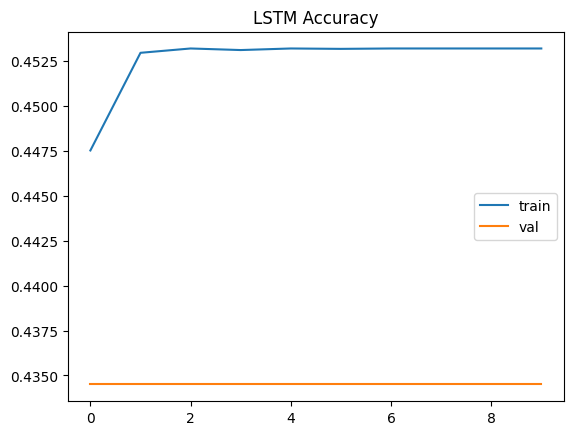

In [ ]:
plt.figure(); plt.plot(hist_lstm.history['accuracy']); plt.plot(hist_lstm.history['val_accuracy'])
plt.title('LSTM Accuracy'); plt.legend(['train','val']); plt.show()

In [ ]:
test_acc = lstm_model.evaluate(X_test,y_test_oh,verbose=0)[1]
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 48.33%


In [ ]:
y_pred = lstm_model.predict(X_test).argmax(axis=1)
print(classification_report(y_test,y_pred , target_names = ["neg" , "neu" , "pos"]))

384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

         neg       0.00      0.00      0.00      3972
         neu       0.48      1.00      0.65      5937
         pos       0.00      0.00      0.00      2375

    accuracy                           0.48     12284
   macro avg       0.16      0.33      0.22     12284
weighted avg       0.23      0.48      0.31     12284



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
fail_idx = np.where(y_pred != y_test)[0][:10]
for i in fail_idx[:5]:
    print("Tweet:", test_texts[i])
    print("True:", ['neg','neu','pos'][y_test[i]], "| Pred:", ['neg','neu','pos'][y_pred[i]])
    print("-"*60)

Tweet: i think i may be finally in with the in crowd mannequinchallenge grads2014
True: pos | Pred: neu
------------------------------------------------------------
Tweet: wow first hugo chavez and now fidel castro danny glover michael moore oliver stone and sean penn are running out of heroes
True: neg | Pred: neu
------------------------------------------------------------
Tweet: twitter s thankyouobama shows heartfelt gratitude to potus
True: pos | Pred: neu
------------------------------------------------------------
Tweet: take away illegals and dead people and trump wins popular vote too
True: neg | Pred: neu
------------------------------------------------------------
Tweet: onedirection harrystyles cute little dance
True: pos | Pred: neu
------------------------------------------------------------


In [ ]:
# Baseline dense-only model for quick comparison
def make_dense_baseline():
    return keras.Sequential([
        layers.Embedding(vocab_size, 64, input_length=max_len),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

In [ ]:

base = make_dense_baseline()
base.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
base.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh), epochs=5, batch_size=128, verbose=0)
print("Baseline test acc:", base.evaluate(X_test, y_test_oh, verbose=0)[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Baseline test acc: 0.5381797552108765


# **Assignment 04 - Transfer Learning : Plant Disease classification**

In [ ]:
import tensorflow_datasets as tfds

In [ ]:
(ds_train,), ds_info = tfds.load(
    'plant_village',
    split=['train'],
    as_supervised=True,
    with_info=True,
)

# Manually split the train dataset into train, validation, and test
train_size = ds_info.splits['train'].num_examples
train_split_size = int(0.7 * train_size)
val_split_size = int(0.15 * train_size)
test_split_size = train_size - train_split_size - val_split_size

ds_train = ds_train.take(train_split_size)
ds_val = ds_train.skip(train_split_size).take(val_split_size)
ds_test = ds_train.skip(train_split_size + val_split_size).take(test_split_size)

In [ ]:
num_class_full = ds_info.features['label'].num_classes
print("Original classes:",num_class_full)

Original classes: 38


In [ ]:
IMG_SIZE = 224
BATCH = 32
AUTO = tf.data.AUTOTUNE

In [ ]:
def to_binary(image,label):
    return image , tf.cast(tf.not_equal(label , healthy_label_tensor),tf.int32)

In [ ]:
class_names = ds_info.features['label'].names
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___

In [ ]:
healthy_idx = [i for i,name in enumerate(class_names) if 'healthy' in name]
print(healthy_idx)

[3, 4, 5, 9, 13, 17, 19, 21, 23, 24, 26, 30]


In [ ]:
healthy_set = tf.constant(healthy_idx,dtype=tf.int32)
healthy_label_tensor = tf.constant(0,dtype=tf.int32)

In [ ]:
def binarize(image,label):
  is_healthy = tf.reduce_any(tf.equal(tf.cast(label,tf.int32),healthy_set))
  y = tf.where(is_healthy,0,1)
  return image , tf.cast(y,tf.int32)

In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [ ]:
aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
train = ds_train.map(binarize,num_parallel_calls=AUTO).map(preprocess,num_parallel_calls=AUTO).map(lambda x, y: (aug(x, training=True), y),num_parallel_calls=AUTO).shuffle(4000).batch(BATCH).prefetch(AUTO)
val = ds_val.map(binarize,num_parallel_calls=AUTO).map(preprocess,num_parallel_calls=AUTO).batch(BATCH).prefetch(AUTO)
test = ds_test.map(binarize,num_parallel_calls=AUTO).map(preprocess,num_parallel_calls=AUTO).batch(BATCH).prefetch(AUTO)

In [ ]:
# train = train.shuffle(4000).batch(BATCH).map(lambda x,y: (aug(x,training=True),y),num_parallel_calls=AUTO).prefetch(AUTO)
# val = val.batch(BATCH).prefetch(AUTO)
# test = test.batch(BATCH).prefetch(AUTO)
#

In [ ]:
from tensorflow.keras.applications import VGG16 , vgg16

In [ ]:
base = VGG16(weights = 'imagenet',include_top=False,input_shape=(IMG_SIZE,IMG_SIZE,3))
base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x = vgg16.preprocess_input(inputs*255.0)
x = base(x,training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64,activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1,activation='sigmoid')(x)

t1_model = keras.Model(inputs,outputs)
t1_model.compile(optimizer=keras.optimizers.Adam(),loss='binary_crossentropy',metrics=['accuracy'])
t1_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     32,832 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,747,585 (56.26 MB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
cb = [
    keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
]
hist = t1_model.fit(train , validation_data=val , epochs=10 , callbacks=cb , verbose=2)
print("Feature extraction test acc :",t1_model.evaluate(test,verbose=0)[1])

Epoch 1/10
1188/1188 - 552s - 465ms/step - accuracy: 0.9415 - loss: 0.1523
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


1188/1188 - 536s - 451ms/step - accuracy: 0.9684 - loss: 0.0862
Epoch 3/10
1188/1188 - 556s - 468ms/step - accuracy: 0.9719 - loss: 0.0749
Epoch 4/10
1188/1188 - 530s - 446ms/step - accuracy: 0.9733 - loss: 0.0697
Epoch 5/10


In [ ]:
# Unfreeze top layers and fien tune with low LR
# Unfreeze last 4 conv blocks from block4_conv1
for layer in base.layers:
    if 'block4' in layer.name or 'block5' in layer.name:
      layer.trainable = True
    else:
      layer.trainable = False

t1_model.compile(optimizer=keras.optimizers.Adam(1e-5),loss='binary_crossentropy',metrics=['accuracy'])
t1_model.summary()


In [ ]:
hist_ft = t1_model.fit(train , validation_data=val , epochs=10 , callbacks=cb , verbose=2)
print("Fine tuning test acc :",t1_model.evaluate(test,verbose=0)[1])

In [ ]:
import itertools

In [ ]:
def collect_samples(dataset, n=16):
    images, labels = [], []
    for x, y in dataset.unbatch().take(200):  # scan some
        images.append(x.numpy()); labels.append(int(y.numpy()))
        if len(images) >= n: break
    return np.array(images), np.array(labels)

imgs, labels = collect_samples(test, n=32)
preds = (tl_model.predict(imgs, verbose=0).ravel() > 0.5).astype(int)

fig, axes = plt.subplots(4,8, figsize=(12,6))
for ax, img, y, p in zip(axes.ravel(), imgs, labels, preds):
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"T:{y} P:{p}", color=("green" if y==p else "red"))
plt.tight_layout(); plt.show()